In [2]:
import pandas as pd
import geopandas as gpd
import contextily

data_dir = "data/Traffic_Crashes_-_Crashes_20260625.csv"
df = pd.read_csv(data_dir, low_memory=False)

In [41]:
causes = list(df.PRIM_CONTRIBUTORY_CAUSE +", " + df.SEC_CONTRIBUTORY_CAUSE.replace("NOT APPLICABLE", ""))
causes = [cause[-2:] if (cause[-2:] == ", ") else cause for cause in causes]
causes = [cause.lower().capitalize() for cause in causes]

In [42]:
causes

['Physical condition of driver, unable to determine',
 'Improper overtaking/passing, improper overtaking/passing',
 ', ',
 ', ',
 ', ',
 'Equipment - vehicle condition, unable to determine',
 ', ',
 'Improper turning/no signal, driving skills/knowledge/experience',
 ', ',
 ', ',
 'Unable to determine, unable to determine',
 'Unable to determine, unable to determine',
 ', ',
 ', ',
 'Unable to determine, unable to determine',
 'Failing to reduce speed to avoid crash, under the influence of alcohol/drugs (use when arrest is effected)',
 'Disregarding stop sign, failing to reduce speed to avoid crash',
 'Improper overtaking/passing, improper lane usage',
 ', ',
 'Unable to determine, unable to determine',
 ', ',
 ', ',
 'Operating vehicle in erratic, reckless, careless, negligent or aggressive manner, weather',
 'Unable to determine, unable to determine',
 ', ',
 'Under the influence of alcohol/drugs (use when arrest is effected), failing to reduce speed to avoid crash',
 'Unable to deter

In [3]:
import json
import numpy as np


def incident_duration_seconds(injuries_total, injuries_fatal):
    """Simple severity-based rule for how long the incident lasts (seconds).

    fatal        -> 120 min
    3+ injuries  ->  90 min
    1-2 injuries ->  45 min
    none         ->  30 min
    """
    minutes = np.where(
        injuries_fatal > 0, 120,
        np.where(injuries_total >= 3, 90,
        np.where(injuries_total >= 1, 45, 30)))
    return (minutes * 60).astype(int)


def crashes_to_jsonl(df, path, drop_null_island=True):
    """Convert the crashes df to JSONL with one record per crash.

    Each record has:
      - date:              crash date as YYYY-MM-DD
      - seconds:           seconds elapsed from midnight to the crash time
      - duration_seconds:  modeled incident length (severity-based rule)
      - end_seconds:       seconds + duration (may exceed 86400 if it spills past midnight)
      - x, y:              longitude, latitude
      - weather:           WEATHER_CONDITION
      - injuries_total:    INJURIES_TOTAL
    """
    ts = pd.to_datetime(df["CRASH_DATE"], format="%m/%d/%Y %I:%M:%S %p")
    seconds = ts.dt.hour * 3600 + ts.dt.minute * 60 + ts.dt.second

    injuries_total = pd.to_numeric(df["INJURIES_TOTAL"], errors="coerce").fillna(0).astype(int)
    injuries_fatal = pd.to_numeric(df["INJURIES_FATAL"], errors="coerce").fillna(0).astype(int)
    duration = incident_duration_seconds(injuries_total.values, injuries_fatal.values)

    out = pd.DataFrame({
        "date": ts.dt.strftime("%Y-%m-%d"),
        "seconds": seconds.astype(int),
        "duration_seconds": duration,
        "end_seconds": seconds.astype(int) + duration,
        "weather": df["WEATHER_CONDITION"],
        "injuries_total": injuries_total,
        "x": pd.to_numeric(df["LONGITUDE"], errors="coerce"),
        "y": pd.to_numeric(df["LATITUDE"], errors="coerce"),
    })

    # drop rows with missing coords, and the "POINT (0 0)" null-island junk
    out = out.dropna(subset=["x", "y"])
    if drop_null_island:
        out = out[(out["x"] != 0) & (out["y"] != 0)]

    with open(path, "w") as f:
        for rec in out.to_dict(orient="records"):
            f.write(json.dumps(rec) + "\n")

    return out


In [6]:
records = crashes_to_jsonl(df, "data/incidents.jsonl")
print(f"wrote {len(records)} records")
records.head()

wrote 1059821 records


,date,seconds,duration_seconds,end_seconds,weather,injuries_total,x,y
3,2020-07-27,34200,1800,36000,RAIN,0,-87.620768,41.797460
4,2020-08-10,59400,1800,61200,RAIN,0,-87.800059,41.790535
9,2020-09-03,25200,1800,27000,CLEAR,0,-87.688939,42.019418
12,2020-08-15,79200,1800,81000,CLEAR,0,-87.675234,41.834227
40,2020-08-30,6600,1800,8400,CLEAR,0,-87.721926,41.862448


In [8]:
records

,date,seconds,duration_seconds,end_seconds,weather,injuries_total,x,y
3,2020-07-27,34200,1800,36000,RAIN,0,-87.620768,41.797460
4,2020-08-10,59400,1800,61200,RAIN,0,-87.800059,41.790535
9,2020-09-03,25200,1800,27000,CLEAR,0,-87.688939,42.019418
12,2020-08-15,79200,1800,81000,CLEAR,0,-87.675234,41.834227
40,2020-08-30,6600,1800,8400,CLEAR,0,-87.721926,41.862448
...,...,...,...,...,...,...,...,...
1068151,2023-07-18,51000,1800,52800,CLEAR,0,-87.738679,41.778580
1068152,2023-06-26,60600,1800,62400,CLEAR,0,-87.644077,41.746905
1068153,2022-12-16,43800,1800,45600,CLEAR,0,-87.667838,41.916235
1068154,2019-12-28,4560,1800,6360,CLEAR,0,-87.628557,41.685142


mean crashes per day: 263.8  (over 4018 days)

top 10 days:
            crashes primary_weather
date                               
2026-01-14     1143      SNOW — 57%
2025-02-06      758     CLEAR — 35%
2019-01-12      582      SNOW — 84%
2024-11-21      568      SNOW — 71%
2020-02-14      563     CLEAR — 85%
2017-11-10      559      SNOW — 50%
2019-11-12      547     CLEAR — 72%
2021-10-29      506      RAIN — 85%
2021-12-10      489      RAIN — 62%
2021-09-17      472     CLEAR — 83%

days at the mean crash count (264 crashes): 25 days
            crashes primary_weather
date                               
2021-12-24      264     CLEAR — 72%
2021-03-06      264     CLEAR — 95%
2019-12-15      264     CLEAR — 89%
2023-12-17      264     CLEAR — 54%
2020-06-27      264     CLEAR — 92%
2019-10-24      264     CLEAR — 90%
2021-04-08      264      RAIN — 55%
2022-03-26      264     CLEAR — 73%
2018-03-27      264     CLEAR — 63%
2022-12-08      264     CLEAR — 88%
2020-03-14      264    

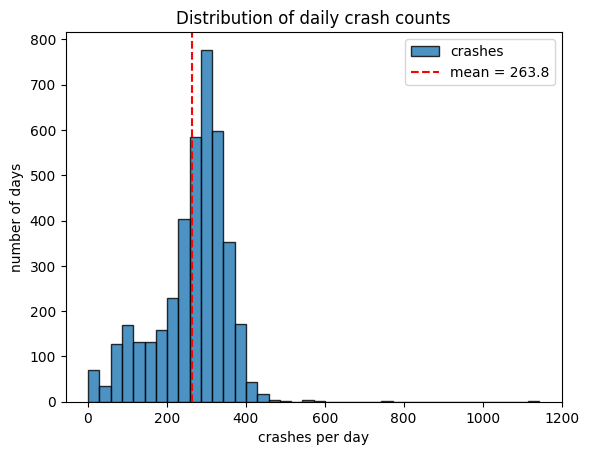

In [35]:
import matplotlib.pyplot as plt


def _primary_weather(s):
    """Most common weather that day as 'NAME — XX%'."""
    counts = s.value_counts(normalize=True)
    if counts.empty:
        return None
    return f"{counts.index[0]} \u2014 {counts.iloc[0]:.0%}"


def crashes_per_day(records):
    """Daily crash counts with each day's primary weather (name + percent)."""
    return (
        records.groupby("date")
        .agg(crashes=("date", "size"), primary_weather=("weather", _primary_weather))
        .sort_values("crashes", ascending=False)
    )


per_day = crashes_per_day(records)

mean_crashes = per_day["crashes"].mean()
print(f"mean crashes per day: {mean_crashes:.1f}  (over {len(per_day)} days)")

# top n days
print("\ntop 10 days:")
print(per_day.head(10))

# days that correspond to the mean crash count (nearest count actually present)
target = per_day["crashes"].iloc[(per_day["crashes"] - mean_crashes).abs().argmin()]
mean_days = per_day[per_day["crashes"] == target]
print(f"\ndays at the mean crash count ({target} crashes): {len(mean_days)} days")
print(mean_days)

# distribution of daily crash counts
ax = per_day["crashes"].plot.hist(bins=40, edgecolor="black", alpha=0.8)
ax.axvline(mean_crashes, color="red", linestyle="--", label=f"mean = {mean_crashes:.1f}")
ax.set_xlabel("crashes per day")
ax.set_ylabel("number of days")
ax.set_title("Distribution of daily crash counts")
ax.legend()
plt.show()

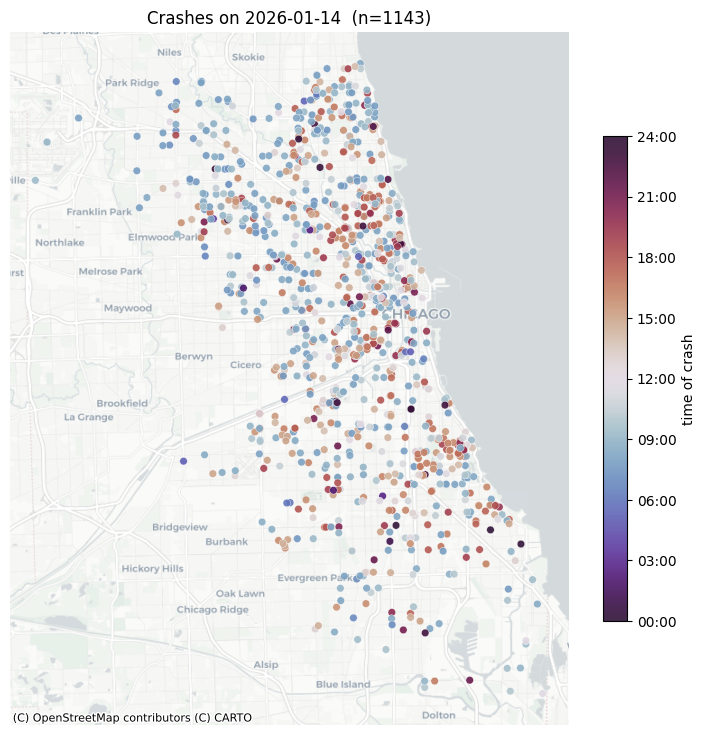

,date,seconds,duration_seconds,end_seconds,x,y,weather,injuries_total
1828,2026-01-14,56940,1800,58740,-87.666298,41.947142,SNOW,0
4843,2026-01-14,52080,1800,53880,-87.668506,41.806856,CLEAR,0
5215,2026-01-14,24000,1800,25800,-87.784675,41.909261,CLEAR,0
5773,2026-01-14,27000,1800,28800,-87.748179,41.989842,BLOWING SNOW,0
7602,2026-01-14,36000,1800,37800,-87.637682,41.896653,SNOW,0
...,...,...,...,...,...,...,...,...
1041449,2026-01-14,32400,1800,34200,-87.737098,41.939070,SNOW,0
1041731,2026-01-14,59400,1800,61200,-87.726016,41.887785,CLEAR,0
1041773,2026-01-14,60300,1800,62100,-87.653230,41.891232,SLEET/HAIL,0
1043387,2026-01-14,66600,1800,68400,-87.668344,41.934338,CLEAR,0


In [ ]:
import contextily as cx
import matplotlib.ticker as mticker


def map_crashes(records, day):
    """Map the crashes for a given day ('YYYY-MM-DD') on a basemap, colored by time of crash."""
    sel = records[records["date"] == day]
    if sel.empty:
        print(f"no crashes for {day}")
        return

    # lon/lat (EPSG:4326) -> Web Mercator (EPSG:3857) for the basemap
    gdf = gpd.GeoDataFrame(
        sel, geometry=gpd.points_from_xy(sel["x"], sel["y"]), crs="EPSG:4326"
    ).to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(9, 9))
    sc = ax.scatter(
        gdf.geometry.x, gdf.geometry.y,
        c=gdf["seconds"], cmap="twilight_shifted",
        vmin=0, vmax=86400, s=30, alpha=0.9, edgecolor="white", linewidth=0.3,
    )
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
    ax.set_axis_off()
    ax.set_title(f"Crashes on {day}  (n={len(sel)})")

    cbar = fig.colorbar(sc, ax=ax, label="time of crash", shrink=0.7)
    cbar.set_ticks(range(0, 86401, 3 * 3600))
    cbar.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda s, _: f"{int(s) // 3600:02d}:{int(s) % 3600 // 60:02d}")
    )
    plt.show()
    return sel


day = "2026-01-14"  # <- change to any 'YYYY-MM-DD' present in the data
map_crashes(records, day)

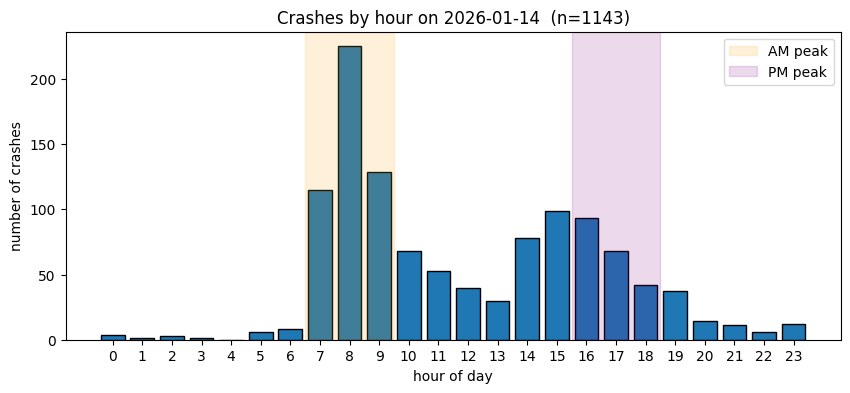

seconds
0       4
1       1
2       3
3       1
4       0
5       6
6       8
7     115
8     225
9     129
10     68
11     53
12     40
13     30
14     78
15     99
16     93
17     68
18     42
19     37
20     14
21     11
22      6
23     12
Name: count, dtype: int64

In [43]:
def crashes_per_hour(records, day):
    """Crashes by hour of day (0-23) for a given day ('YYYY-MM-DD') to inspect AM/PM peak flows."""
    sel = records[records["date"] == day]
    if sel.empty:
        print(f"no crashes for {day}")
        return

    hour = (sel["seconds"] // 3600).astype(int)
    by_hour = hour.value_counts().reindex(range(24), fill_value=0).sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(by_hour.index, by_hour.values, edgecolor="black")
    ax.axvspan(6.5, 9.5, color="orange", alpha=0.15, label="AM peak")
    ax.axvspan(15.5, 18.5, color="purple", alpha=0.15, label="PM peak")
    ax.set_xticks(range(24))
    ax.set_xlabel("hour of day")
    ax.set_ylabel("number of crashes")
    ax.set_title(f"Crashes by hour on {day}  (n={len(sel)})")
    ax.legend()
    plt.show()
    return by_hour


crashes_per_hour(records, day)